<a href="https://colab.research.google.com/github/rinlopable/PCD_Assignment02/blob/main/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCD_Assignment02

## Low-Contrast Image Enhancement Using Contrast Stretching

**Name:** Ni Wayan Regina Raytana Putri  
**Student ID:** 25/558695/PA/23481

## 1. Introduction

Image enhancement is used to improve the quality of an image so that its details can be seen more clearly. One common image problem is low contrast, where the difference between darker and brighter areas becomes less noticeable, making the image look faded or flat.

In this assignment, I will work with four different original images. The contrast of each image will first be reduced to create low-contrast test images. After that, Contrast Stretching will be applied to enhance them.

The results will be compared visually and using PSNR (Peak Signal-to-Noise Ratio) to see whether the enhanced images become closer to the original reference images.

## 2. Objectives

The objectives of this assignment are:

- To create low-contrast versions of four original images.
- To enhance the low-contrast images using Contrast Stretching.
- To compare the images before and after enhancement visually.
- To compare the PSNR values before and after enhancement using the original images as references.
- To analyze how effective Contrast Stretching is for improving low-contrast images.

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [51]:
repo_url = "https://github.com/rinlopable/PCD_Assignment02.git"
repo_path = "/content/PCD_Assignment02"

if os.path.exists(repo_path):
    %cd /content/PCD_Assignment02
    !git pull
else:
    %cd /content
    !git clone {repo_url}

/content/PCD_Assignment02
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 8.74 MiB | 7.31 MiB/s, done.
From https://github.com/rinlopable/PCD_Assignment02
   7f485d8..5548cf4  main       -> origin/main
Updating 176dc0f..5548cf4
Fast-forward
 PCD_Assignment02.ipynb | 741 ++++++++++++++++++++++++++++++++++++++++++++++---
 1 file changed, 705 insertions(+), 36 deletions(-)


In [52]:
original_folder = "/content/PCD_Assignment02/images/original"

print(os.listdir(original_folder))

['original_02.JPG', 'original_04.JPG', 'original_01.JPG', 'README.md', 'original_03.JPG']


In [53]:
image_paths = [
    f"{original_folder}/original_01.JPG",
    f"{original_folder}/original_02.JPG",
    f"{original_folder}/original_03.JPG",
    f"{original_folder}/original_04.JPG"
]

original_images = []

for path in image_paths:
    image = cv2.imread(path)
    original_images.append(image)

print("Number of images loaded:", len(original_images))

for i, image in enumerate(original_images):
    if image is None:
        print(f"Image {i + 1}: failed to load")
    else:
        print(f"Image {i + 1}: loaded successfully - shape {image.shape}")

Number of images loaded: 4
Image 1: loaded successfully - shape (675, 1200, 3)
Image 2: loaded successfully - shape (675, 1200, 3)
Image 3: loaded successfully - shape (675, 1200, 3)
Image 4: loaded successfully - shape (675, 1200, 3)


## 3. Original Images

Four different images are used as the original reference images in this experiment. These images will later be modified to create low-contrast versions, while the original images will be kept as references for visual comparison and PSNR calculation.

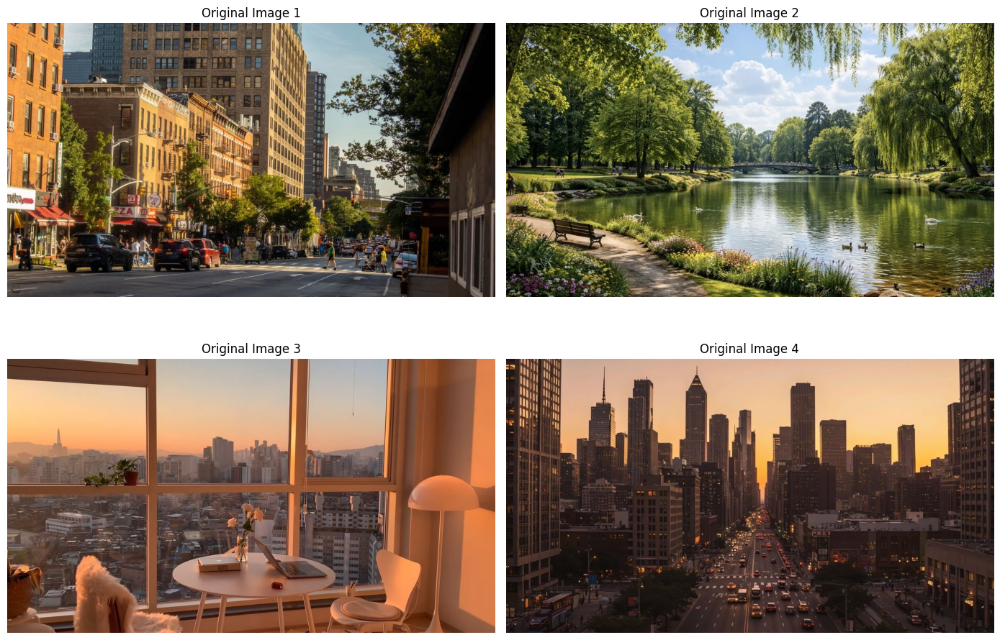

In [54]:
plt.figure(figsize=(14, 10))

for i, image in enumerate(original_images):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image_rgb)
    plt.title(f"Original Image {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Creating Low-Contrast Images

To create the test images, I reduced the contrast of all four original images using the same contrast factor. This makes the experiment more consistent because every image is degraded using the same setting.

The contrast is reduced by moving the pixel values closer to the middle intensity value. This makes the difference between dark and bright areas smaller, so the image looks flatter and has lower contrast.

For all four images, I used the same parameters:

- α = 0.5
- β = 64

The low-contrast image is created using:

**Y_low = αY + β**

where Y represents the luminance or brightness channel. Using α = 0.5 reduces the distance between dark and bright intensity values, while β = 64 shifts the values toward the middle intensity range.

Low-contrast images created: 4


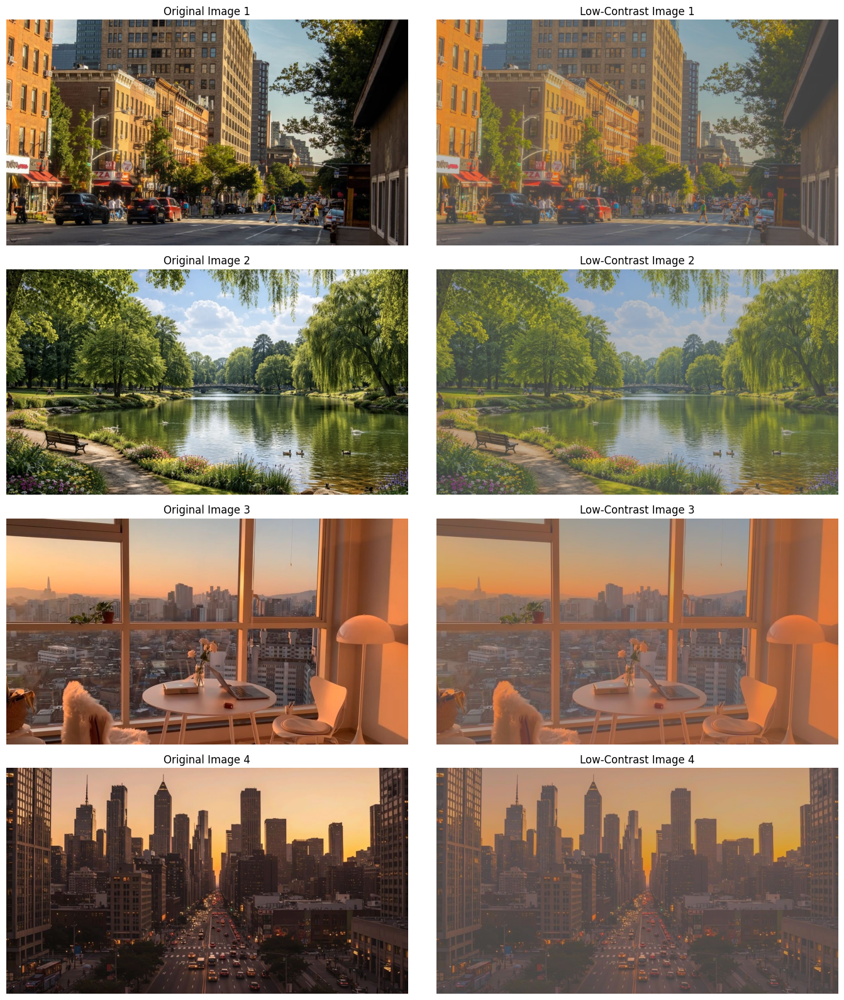

In [55]:
alpha = 0.5
beta = 64

low_contrast_images = []

for image in original_images:
    # Convert BGR to YCrCb
    ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)

    # Take the Y channel (brightness)
    y_channel = ycrcb[:, :, 0]

    # Reduce only the brightness contrast
    low_y = alpha * y_channel + beta
    low_y = np.clip(low_y, 0, 255).astype(np.uint8)

    # Replace the original Y channel
    ycrcb[:, :, 0] = low_y

    # Convert back to BGR
    low_contrast = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

    low_contrast_images.append(low_contrast)

print("Low-contrast images created:", len(low_contrast_images))

plt.figure(figsize=(14, 16))

for i in range(4):
    original_rgb = cv2.cvtColor(original_images[i], cv2.COLOR_BGR2RGB)
    low_rgb = cv2.cvtColor(low_contrast_images[i], cv2.COLOR_BGR2RGB)

    plt.subplot(4, 2, (i * 2) + 1)
    plt.imshow(original_rgb)
    plt.title(f"Original Image {i + 1}")
    plt.axis("off")

    plt.subplot(4, 2, (i * 2) + 2)
    plt.imshow(low_rgb)
    plt.title(f"Low-Contrast Image {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
low_contrast_folder = "/content/PCD_Assignment02/images/low_contrast"

for i, image in enumerate(low_contrast_images):
    output_path = f"{low_contrast_folder}/low_contrast_{i + 1:02d}.JPG"
    cv2.imwrite(output_path, image)

print("Low-contrast images saved successfully!")
print(os.listdir(low_contrast_folder))

Low-contrast images saved successfully!
['low_contrast_02.JPG', 'low_contrast_03.JPG', 'low_contrast_01.JPG', 'README.md', 'low_contrast_04.JPG']


## 5. Contrast Stretching

After creating the low-contrast images, I applied Contrast Stretching to increase the difference between dark and bright pixel values.

Contrast Stretching works by expanding the intensity range of an image. The minimum intensity is mapped closer to 0, while the maximum intensity is mapped closer to 255. This makes the darker and brighter areas more distinguishable and improves the overall contrast.

The contrast stretching process can be written as:

**P_out = (P_in - Min) × (255 / (Max - Min))**

where `Min` and `Max` are the minimum and maximum intensity values of the input image.

The enhancement is applied only to the Y (luminance) channel in the YCrCb color space, so the image contrast can be improved while preserving the original color information.

In [57]:
def contrast_stretching(image):
    ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)

    y_channel = ycrcb[:, :, 0]

    min_value = np.min(y_channel)
    max_value = np.max(y_channel)

    stretched_y = (y_channel - min_value) * (255.0 / (max_value - min_value))
    stretched_y = np.clip(stretched_y, 0, 255).astype(np.uint8)

    ycrcb[:, :, 0] = stretched_y

    stretched_image = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

    return stretched_image

enhanced_images = []

for image in low_contrast_images:
    enhanced = contrast_stretching(image)
    enhanced_images.append(enhanced)

print("Enhanced images created:", len(enhanced_images))

Enhanced images created: 4


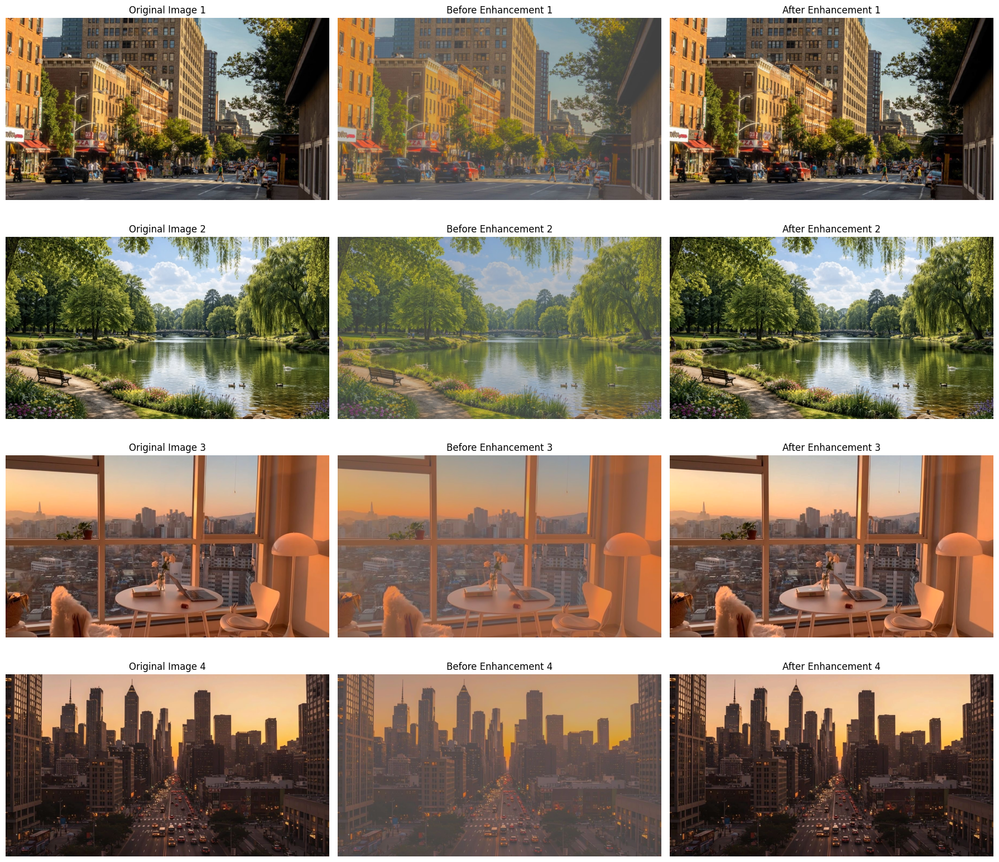

In [58]:
plt.figure(figsize=(18, 16))

for i in range(4):
    original_rgb = cv2.cvtColor(original_images[i], cv2.COLOR_BGR2RGB)
    low_rgb = cv2.cvtColor(low_contrast_images[i], cv2.COLOR_BGR2RGB)
    enhanced_rgb = cv2.cvtColor(enhanced_images[i], cv2.COLOR_BGR2RGB)

    plt.subplot(4, 3, (i * 3) + 1)
    plt.imshow(original_rgb)
    plt.title(f"Original Image {i + 1}")
    plt.axis("off")

    plt.subplot(4, 3, (i * 3) + 2)
    plt.imshow(low_rgb)
    plt.title(f"Before Enhancement {i + 1}")
    plt.axis("off")

    plt.subplot(4, 3, (i * 3) + 3)
    plt.imshow(enhanced_rgb)
    plt.title(f"After Enhancement {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. PSNR Evaluation

To evaluate the enhancement result, I used PSNR (Peak Signal-to-Noise Ratio). The original images are used as the reference images.

For each image, I calculated two PSNR values:

- **PSNR Before Enhancement:** compares the original image with the low-contrast image.
- **PSNR After Enhancement:** compares the original image with the enhanced image.

A higher PSNR value means that the image is closer to the original reference image.

In [59]:
psnr_before = []
psnr_after = []

for i in range(4):
    before = cv2.PSNR(original_images[i], low_contrast_images[i])
    after = cv2.PSNR(original_images[i], enhanced_images[i])

    psnr_before.append(before)
    psnr_after.append(after)

    print(f"Image {i + 1}")
    print(f"PSNR Before Enhancement : {before:.2f} dB")
    print(f"PSNR After Enhancement  : {after:.2f} dB")
    print()

print("PSNR Comparison")
print("-" * 58)
print(f"{'Image':<10}{'Before (dB)':<18}{'After (dB)':<18}{'Change':<12}")
print("-" * 58)

for i in range(4):
    change = psnr_after[i] - psnr_before[i]

    print(
        f"{'Image ' + str(i + 1):<10}"
        f"{psnr_before[i]:<18.2f}"
        f"{psnr_after[i]:<18.2f}"
        f"{change:+.2f}"
    )

average_before = np.mean(psnr_before)
average_after = np.mean(psnr_after)

print(f"Average PSNR Before Enhancement : {average_before:.2f} dB")
print(f"Average PSNR After Enhancement  : {average_after:.2f} dB")
print(f"Average Improvement             : {average_after - average_before:+.2f} dB")

Image 1
PSNR Before Enhancement : 17.03 dB
PSNR After Enhancement  : 50.83 dB

Image 2
PSNR Before Enhancement : 17.47 dB
PSNR After Enhancement  : 50.90 dB

Image 3
PSNR Before Enhancement : 19.72 dB
PSNR After Enhancement  : 32.26 dB

Image 4
PSNR Before Enhancement : 15.87 dB
PSNR After Enhancement  : 41.61 dB

PSNR Comparison
----------------------------------------------------------
Image     Before (dB)       After (dB)        Change      
----------------------------------------------------------
Image 1   17.03             50.83             +33.80
Image 2   17.47             50.90             +33.43
Image 3   19.72             32.26             +12.54
Image 4   15.87             41.61             +25.74
Average PSNR Before Enhancement : 17.52 dB
Average PSNR After Enhancement  : 43.90 dB
Average Improvement             : +26.38 dB


In [60]:
enhanced_folder = "/content/PCD_Assignment02/images/enhanced"

for i, image in enumerate(enhanced_images):
    output_path = f"{enhanced_folder}/enhanced_{i + 1:02d}.JPG"
    cv2.imwrite(output_path, image)

print("Enhanced images saved successfully!")

print("Low-contrast files:")
print(os.listdir(low_contrast_folder))

print("\nEnhanced files:")
print(os.listdir(enhanced_folder))

Enhanced images saved successfully!
Low-contrast files:
['low_contrast_02.JPG', 'low_contrast_03.JPG', 'low_contrast_01.JPG', 'README.md', 'low_contrast_04.JPG']

Enhanced files:
['enhanced_01.JPG', 'enhanced_03.JPG', 'enhanced_04.JPG', 'enhanced_02.JPG', 'README.md']


### PSNR Comparison

| Image | Before Enhancement | After Enhancement | Improvement |
|---|---:|---:|---:|
| Image 1 | 17.03 dB | 50.83 dB | +33.80 dB |
| Image 2 | 17.47 dB | 50.90 dB | +33.43 dB |
| Image 3 | 19.72 dB | 32.26 dB | +12.54 dB |
| Image 4 | 15.87 dB | 41.61 dB | +25.74 dB |
| **Average** | **17.52 dB** | **43.90 dB** | **+26.38 dB** |

## 7. Result Analysis

From the visual comparison, all four low-contrast images became clearer after Contrast Stretching was applied. The difference between the darker and brighter areas became more noticeable, and the overall appearance became much closer to the original images.

The PSNR results also show a clear improvement. Before enhancement, the average PSNR was 17.52 dB. After applying Contrast Stretching, it increased to 43.90 dB, giving an average improvement of 26.38 dB.

Images 1 and 2 had the highest PSNR after enhancement, reaching 50.83 dB and 50.90 dB. This means that their enhanced versions were very close to their original reference images. Image 4 also showed a large improvement from 15.87 dB to 41.61 dB.

The very high PSNR values for Images 1 and 2 are also related to how the low-contrast images were created. Since the contrast was reduced using a controlled linear transformation and then enhanced using another linear transformation, Contrast Stretching could recover intensity values that were very close to the original images.

Image 3 had a smaller improvement compared to the other images, from 19.72 dB to 32.26 dB. Even though its PSNR improvement was lower, the enhanced image still looked noticeably clearer than the low-contrast version.

Overall, both the visual comparison and PSNR values show that Contrast Stretching was effective in improving the low-contrast images.

## 8. Conclusion

In this assignment, I tested Contrast Stretching on four low-contrast images. The low-contrast images were created by reducing the contrast of the luminance channel, while keeping the color information unchanged.

After applying Contrast Stretching, all four images showed clearer differences between dark and bright areas. The visual results also became much closer to the original reference images.

The PSNR results support this improvement. The average PSNR increased from 17.52 dB before enhancement to 43.90 dB after enhancement, with an average improvement of 26.38 dB.

Based on both the visual comparison and PSNR values, Contrast Stretching was effective for improving the low-contrast images used in this experiment.